Covers the topics of:
- Backpropagation

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
  return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

### What `np.arange(-5, 5, 0.25)` does

`np.arange(-5, 5, 0.25)` creates a NumPy array of numbers:

- starting at `-5`
- increasing by `0.25`
- stopping **before** `5`

So it produces values like:

```python
[-5.00, -4.75, -4.50, -4.25, ..., 4.50, 4.75]

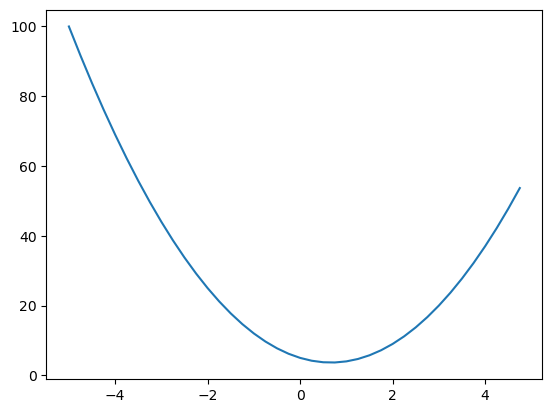

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
# back to school
# understanding the concept of slope in calculus.

h = 0.000001
x = 3
(f(x + h) - f(x))/h

14.000003002223593

In [6]:
h = 0.0000000000000001
x = 3
(f(x + h) - f(x))/h

0.0

PROBLEM: we encountered out of scope problem with the value being `0`. Lets say float has a finite size, which means its MSB will have a limit. 
- So neural networks with FP4 might have to compromise with the value of weights compared with FP16. 
- We can some to that later. But for example would be DeepSeek R1

In [7]:
# lets get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [8]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


### Significance of `__add__` in this code

`__add__` is a special Python method used for the `+` operator.

In this code:

```python
c = a + b

Why you cannot replace __add__ with any other keyword
You cannot use just any name because __add__ is a special reserved method name in Python's data model.

Python looks specifically for:

__add__ for +
__sub__ for -
__mul__ for *
__truediv__ for /
If you rename it to something else, 

In [9]:
class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        # _children is an empty tuple
        # _prev will be the empty set.
        self.grad = 0.0 # that means initially it has no effect
        self.data = data
        self._prev = set(_children) # designing it as a set; will have to see. might just be an efficiency thing. 
        self._op = _op # store which operation we did
        self.label = label # store the variable name. 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+') # this line is calling the __init__ itself
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') # this line is calling the __init__ itself
        return out

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e' 
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
# e._prev

In [10]:
# e._prev = {Value(data=-3.0), Value(data=2.0)} ------- but how?
# in this line: 
# e = a*b; e.label = 'e'
# a+b calls the Value.__mul__() method -> REASON -> a and b both are objects of class 'Value'
# so a.__mul__(b) is called, therefore:-
# self <- a
# other <- b
# inside the __mul__ it calls:-
# out = Value(self.data * other.data, (self, other), '*') ----- the constructor is called 
# out = Value(2.0 * (-3.0), (a, b), '*')
# NOW: _children = (a, b) ; _op = '*' ; label = '' ----- FROM THE CONSTRUCTOR
# THEN: self._prev = set((a, b))
# i.e. e._prev = {a, b}
# and now when we are trying to display `e` then the output is `{Value(data=-3.0) * Value(data=2.0)}` = -6
# REASON: 
# `__repr__` is called when Python needs the **string representation** of an object, usually for debugging or display.
# In your class:
# def __repr__(self):
#     return f"Value(data={self.data})"

Graph Visualization (calling the graphviz api)

In [11]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

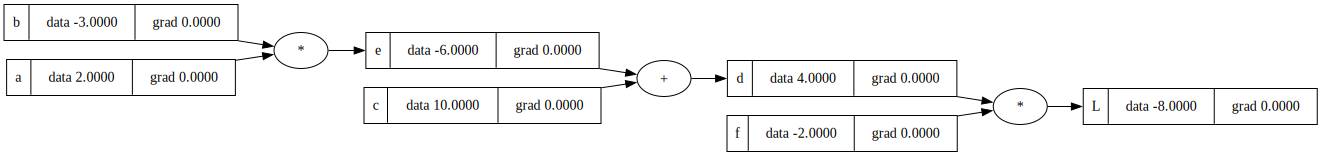

In [12]:
# This diagram is without taking into consideration of any gradients. Gradient calculation follow below.
draw_dot(L)

In [13]:
# EXAMPLE: 
# here the grad of `f` is the derivative of the output which in this case is `L` w.r.t. `f`

Computing backpropagation manually. Understanding `dy/dx`

1. dL/dL

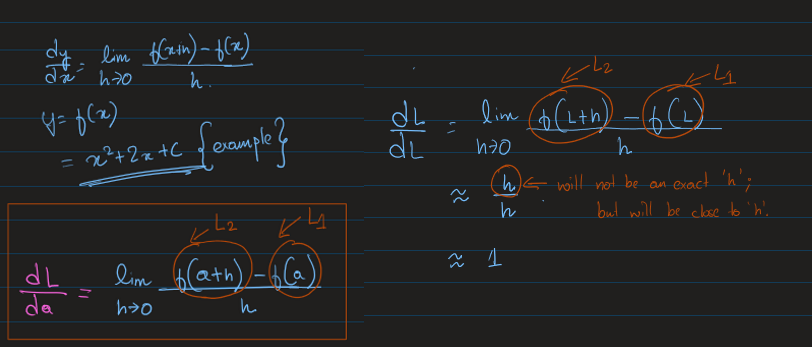

In [14]:
L.grad = 1.0 # setting it manually, the explanation is in the screenshot above

finding out $dL/da$ using the `lol()` function directly.  
In the following blocks we would be proving that by chain rule, i.e. manual `backpropagation`

In [15]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e' 
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0 + h, label='a') # if we add `h' to a; then its dL/da
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e' 
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h)

lol() # this is dL/da; and 6 is the value. Now we would be proving that by chain rule. (AKA backpropagation)

6.000000000021544


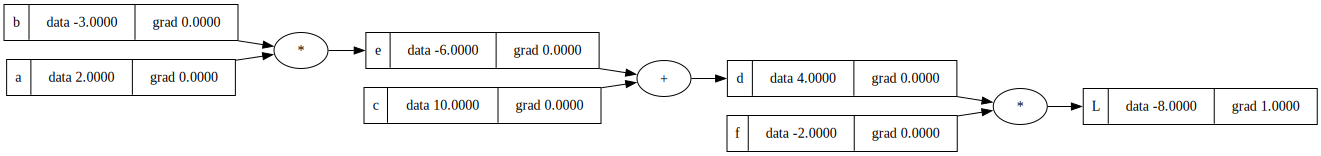

In [16]:
# After setting the L.grad, we are re-plotting the graph
draw_dot(L)

2. dL/dd & dL/df

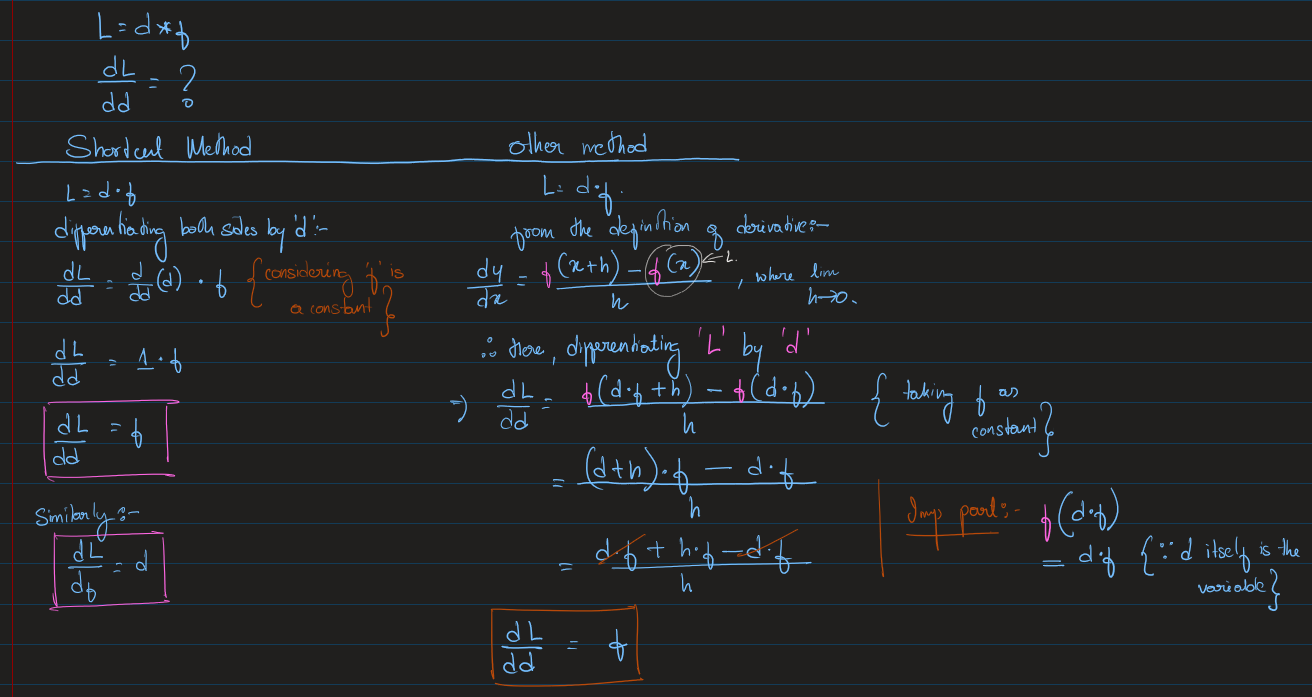

In [17]:
# So manually we now know that:
f.grad = 4.0 # i.e. value of d
d.grad = -2 # i.e. value of f 

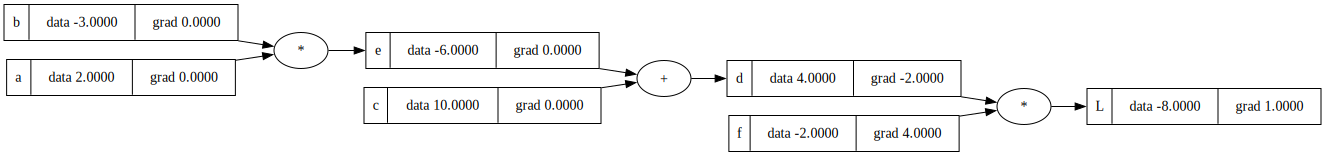

In [18]:
draw_dot(L)

In [19]:
# Now numerically verifying d.grad using the lol() function.
# this is the inline gradient check. 
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e' 
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a') 
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e' 
    d = e+c; d.label = 'd'
    d.data+=h # we added `h' to d; then its dL/dd
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'

    L2 = L.data

    print((L2-L1)/h)

lol() # the value does match with our mathematical calculation of d.grad = -2

-1.9999999999953388


3. dL/dc 

## Chain rule in differentiation:-  
Difficult form: (Not for me :P )

$$
h'(x) = f'(g(x))\,g'(x)
$$

$$
h' = (f \circ g)' = (f' \circ g)\cdot g'
$$

Easy form:

$$
\frac{dz}{dx} = \frac{dz}{dy}\cdot\frac{dy}{dx}
$$

$$
\left.\frac{dz}{dx}\right|_{x}
=
\left.\frac{dz}{dy}\right|_{y(x)}
\cdot
\left.\frac{dy}{dx}\right|_{x}
$$

## Now for $\frac{dL}{dc}$ :-


$$
\frac{dL}{dc} = \frac{dL}{dd}\cdot\frac{dd}{dc}
$$

Here $\frac{dL}{dd}$ and $\frac{dd}{dc}$ are called local derivative.  
In a neural network, there can be multiple/numerous local derivatives.  


So now we have to find $\frac{dd}{dc}$.  
As we know ${d = c + e}$,  
so 
$$
\begin{aligned}
\frac{dd}{dc} &= \frac{dc}{dc} + \frac{de}{dc} \\
\text{Therefore, } \frac{dd}{dc} &= 1
\end{aligned}
$$

considering $\frac{de}{dc}$ as constant, because $e$ does not depend on $c$.  

by symmetry/similarly $\frac{dd}{de} = 1$

Now to summarize:-  
$$
\frac{dd}{dc} = 1 \\

\frac{dd}{de} = 1
$$


Now going back to the original equation of $\frac{dL}{dc}$.  
$$
\frac{dL}{dc} = \frac{dL}{dd}\cdot\frac{dd}{dc}  \\
= -2 * 1 \;\;\;\;\;\; \because \frac{dL}{dd} = -2 \text{ from previous calculation, and } \frac{dd}{dc} = 1 \text{ we calculated just above}\\
= -2 \;\; \text{ (Ans)}
$$


In [20]:
c.grad = -2
e.grad = -2
# now re-plotting the graph

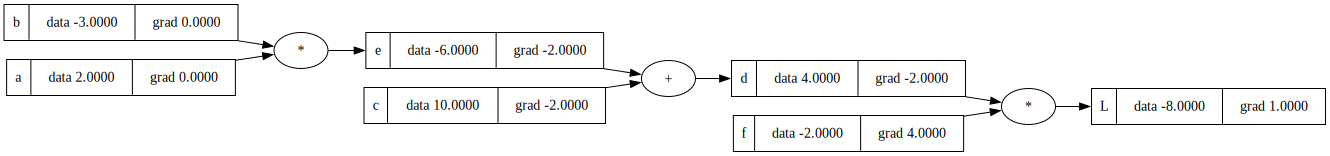

In [21]:
draw_dot(L)

We can also verify the gradient values using the `lol()` function but no need for now.  
Now we know that $\frac{dL}{de} = -2$  
Our objective is :-  
$$
\frac{dL}{da} \text{ and } \frac{dL}{db} = ??
$$  


Now as per chain rule :-  


$$
\begin{aligned}
\frac{dL}{da} &= \frac{dL}{de} \cdot \frac{de}{da}
\end{aligned}
$$

similarly,

$$
\begin{aligned}
\frac{dL}{db} &= \frac{dL}{de} \cdot \frac{de}{db}
\end{aligned}
$$

now as $e = a * b$, so :-  

$$
\frac{de}{da} = \frac{1}{da} \cdot (a*b) \\
\therefore \frac{de}{da} = \frac{da}{da} \cdot b \\ 
\frac{de}{da} = b
$$

similarly,  

$$
\frac{de}{db} = a
$$

Therefore  
$$
\frac{dL}{da} = -2 \cdot \text{ b} \\
\text{which is } \frac{dL}{da} = -2 \cdot -3\\
\boxed{\frac{dL}{da} = 6} \\

\text{similarly}
\frac{dL}{db} = -2 \cdot \text{ a} \\
\boxed{\frac{dL}{db} = -4}
$$

In [22]:
a.grad = 6
b.grad = -4

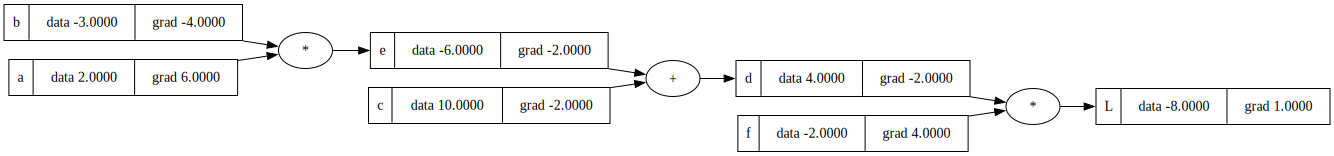

In [23]:
draw_dot(L)

A single step of optimization

In [24]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data) # the gradient determines the final outcome

-7.286496


Implementation of a neuron
1. Break down the neuron into boxes 
2. Manual backpropagation like above

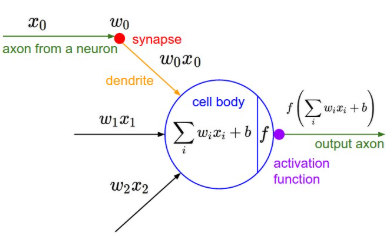

Reference: https://cs231n.github.io/neural-networks-1/

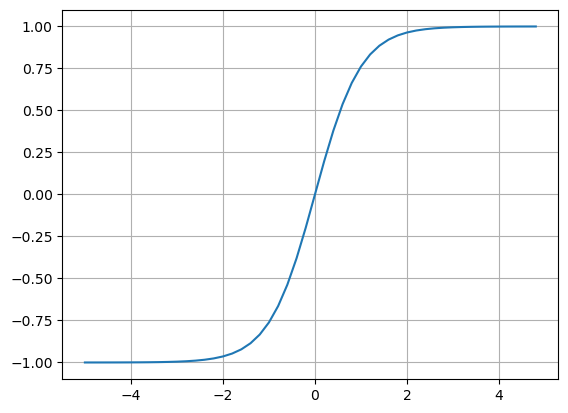

In [25]:
# Lets plot the tanh() function for visualization
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid(); 

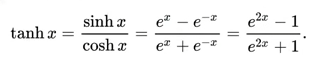

In [26]:
# Now updating and adding the functionality of tanh in the Value class
import math 

class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        # _children is an empty tuple
        # _prev will be the empty set.
        self.grad = 0.0 # that means initially it has no effect
        self.data = data
        self._prev = set(_children) # designing it as a set; will have to see. might just be an efficiency thing. 
        self._op = _op # store which operation we did
        self.label = label # store the variable name. 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+') # this line is calling the __init__ itself
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') # this line is calling the __init__ itself
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1) # basically copying the formula of tanh mathematical expression
        out = Value(t, (self, ), 'tanh') # (self, ) means tuple of itself. 
        # WHY? because tanh() only requires one parameter. i.e. itself. 
        # whereas add() and mul() requires more than 1 parameter. 
        return out


In [27]:
# all the values here are random taken from Andrej's video
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b') # this value is just for calculation convenience

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x1w2' 
x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label = 'x1w1 + x2w2'

n = x1w1_x2w2 + b; n.label = 'n'
# now n is the raw cell body without the activation function.
# the activation function on top of n, we would be using would be tanh()

# adding the output axon `o` on the cell body `n`
o = n.tanh(); o.label = 'o'

## Manual Backpropagation (Part2)

In case of a neural net, its the `w1` and `w2` that changes w.r.t. o.  
That means in case of our manual backpropagation; our objective is:  
$$
\frac{do}{d(w1)} = ?? \\
\text{ and } \\
\frac{do}{d(w2)} = ??
$$

In [28]:
o.grad = 1.0 # gradient with itself is always 1.0

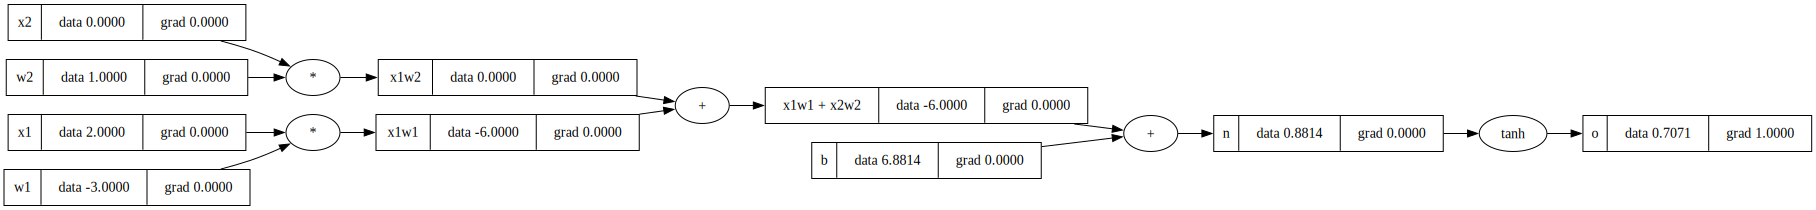

In [29]:
draw_dot(o)

From here we only need the `derivative` of $tanh(x)$
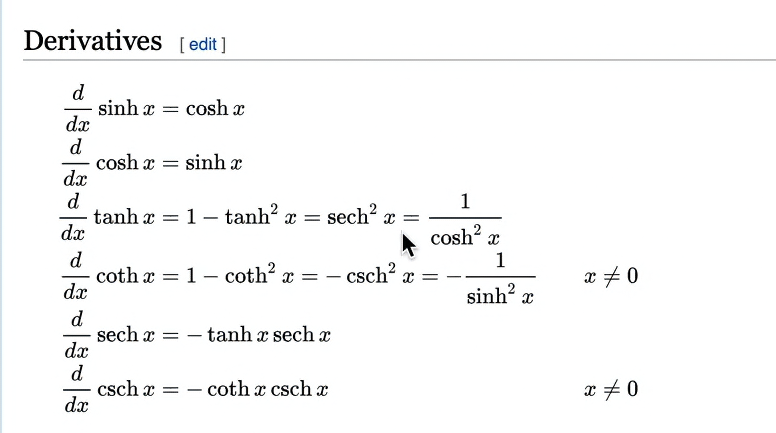

As  
$$
o = \tanh(n) \\
\frac{do}{dn} = 1 - \tanh^2(n) \\
\boxed{\frac{do}{dn} = 1 - o^2} \text{ -----> eqA}
$$


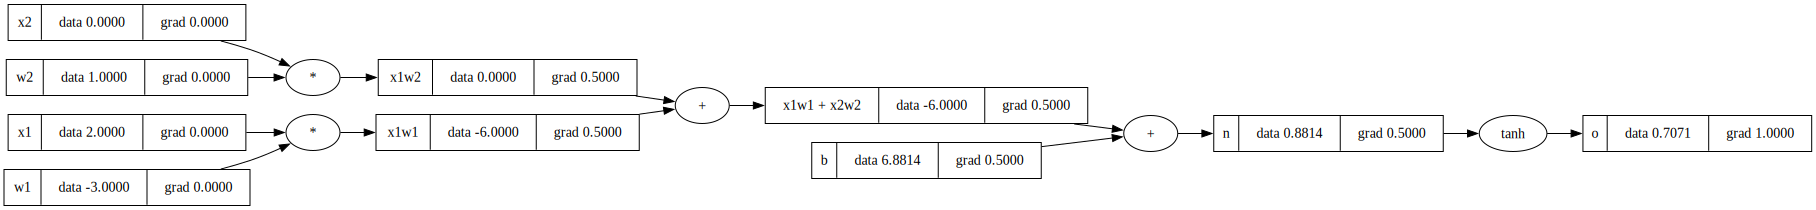

In [30]:
# Therefore
n.grad = (1 - o.data**2) * o.grad # (1 - o.data**2) is the local derivative;
# its always multiplied by the gradient of the child node. 
# Here its o.grad
# draw_dot(o)
# Now as the next operator is `+`, from our previous examples we know the gradient simply gets distributed
# Therefore
b.grad = 0.5
x1w1_x2w2.grad = 0.5
# draw_dot(o)
# Now again there is a `+` operator.
x1w1.grad = 0.5
x2w2.grad = 0.5
draw_dot(o)

<!-- Here `x1w1` is just the name of the variable
$$
x1w1 = x1 * w1 \\
\frac{d(x1w1)}{d(w1)} = \frac{1}{d(w1)} \cdot (x1*w1) \\
\frac{d(x1w1)}{d(w1)} = \frac{d(w1)}{d(w1)} \cdot x1 \\
\frac{d(x1w1)}{d(w1)} = x1
$$ 

Now this is the local derivative, and not the `x1.grad`.  
That will be 
$$
\frac{do}{d(x1)}
$$

and now using chain rule lets find out:-
$$
\frac{do}{d(x1)} = \frac{do}{dn} \cdot \frac{dn}{d(x1w1 + x2w2)} \cdot \frac{d(x1w1 + x2w2)}{d(x1w1)} \cdot \frac{d(x1w1)}{d(x1)} 
$$ -->


For us `x1.grad` is actually $\frac{do}{dx1}$  
Now the question is, how do we find it.  
Taking reference to our previous non-neuron backpropagation derivatives calculations, we can find out that:  
$$
\boxed{\frac{do}{d(x1)} = \frac{do}{d(x1w1)} \cdot \frac{d(x1w1)}{d(x1)}} \text{ -----> eq1 }
$$
Now we know that $\frac{do}{d(x1w1)}$ is actually `x1w1.grad()`.  
And lets take care of:-  
$$
\frac{d(x1w1)}{d(x1)} = \frac{1}{d(x1)} \cdot (x1 * w1) \\
\frac{d(x1w1)}{d(x1)} = \frac{d(x1)}{d(x1)} \cdot (w1) \\
\boxed{\frac{d(x1w1)}{d(x1)} = w1}
$$

Finally replacing the RHS of `eq1` we get:  
$$
\frac{do}{d(x1)} = \text{x1.grad() * w1} \\
\frac{do}{d(x1)} = \text{0.5 * (-3.0)} \\
\boxed{\frac{do}{d(x1)} = -1.5}
$$


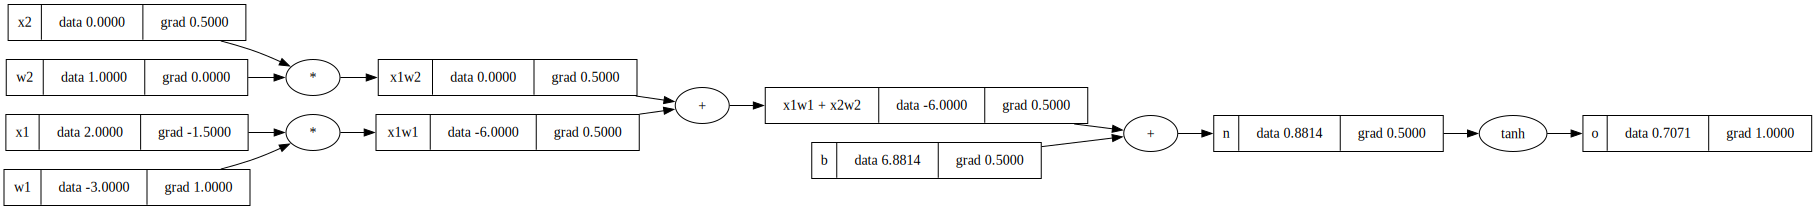

In [31]:
# Therefore
w1.grad = x1.data * x1w1.grad # 2.0 x 0.5
x1.grad = w1.data * x1w1.grad # -3.0 x 0.5
# Similarly
w2.grad = x2.data * x2w2.grad # 0.0 x 0.5
x2.grad = w2.data * x2w2.grad # 1.0 x 0.5
draw_dot(o)

Implementing the Backward Function  
- The job is to backpropagate the gradients to the parents' nodes gradients. 
- The value will differ based on the math operation happening inside the cell body.
- We would be doing that by modifying the `Value` class.


In [32]:
class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        # _children is an empty tuple
        # _prev will be the empty set.
        self.grad = 0.0 # that means initially it has no effect
        self._backward = lambda: None
        self.data = data
        self._prev = set(_children) # designing it as a set; will have to see. might just be an efficiency thing. 
        # This will help in creating the linked-list
        self._op = _op # store which operation we did
        self.label = label # store the variable name. 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+') # this line is calling the __init__ itself

        def _backward():
            # taking reference from our manual backpropagation
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') # this line is calling the __init__ itself
        
        def _backward():
            # taking reference from our manual backpropagation
            self.grad = other.data * out.grad # taking reference from equ 1.
            other.grad = self.data * out.grad
            # But in real backprop, it will not just be other.data; it might be :-
            # (other1.data + other2.data + .....) * out.grad. 
            # This we will have to check. 
        out._backward = _backward
        
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1) # basically copying the formula of tanh mathematical expression
        out = Value(t, (self, ), 'tanh') # (self, ) means tuple of itself. 
        # WHY? because tanh() only requires one parameter. i.e. itself. 
        # whereas add() and mul() requires more than 1 parameter. 

        def _backward(): 
            self.grad = (1 - t**2) * out.grad 
            # or 
            # self.grad = (1 - out.value**2) * out.grad 
        out._backward = _backward

        return out

## NOTES:

### Meaning of `self._backward` here in the `Value` class

- `self._backward` is being set to a function
- that function takes no arguments
- and does nothing

Equivalent idea:

```python
def nothing():
    pass

self._backward = nothing
```

Why it is used in `micrograd`:
- every `Value` object stores a backward function
- for leaf/default nodes, there may be nothing to do yet
- so `lambda: None` is a safe no-op placeholder

So later, code can call:

```python
node._backward()
```

without checking whether `_backward` exists.  
  


### The difference between:- `out._backward = _backward()` and `out._backward = _backward`

Very important difference:

`out._backward = _backward`
- stores the function itself
- does not run it yet
- later you can call:
  ```python
  out._backward()
  ```

`out._backward = _backward()`
- runs `_backward` immediately
- stores the return value of `_backward`
- if `_backward` returns nothing, then:
  ```python
  out._backward = None
  ```
- later `out._backward()` will fail

In `micrograd`, you want:

```python
out._backward = _backward
```

because you are saving the backward function to execute later during backpropagation.

In [33]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b') # this value is just for calculation convenience

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x1w2' 
x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label = 'x1w1 + x2w2'

n = x1w1_x2w2 + b; n.label = 'n'
# now n is the raw cell body without the activation function.
# the activation function on top of n, we would be using would be tanh()

# adding the output axon `o` on the cell body `n`
o = n.tanh(); o.label = 'o'

In [34]:
o.grad = 1.0
o._backward()

In [35]:
n._backward()

In [36]:
b._backward() # Nothing will happen as its a leaf node. (as per the class Value's init function)

In [37]:
x1w1_x2w2._backward()

In [38]:
x1w1._backward()
x2w2._backward()
# This will complete the whole tree of backpropagation manually.

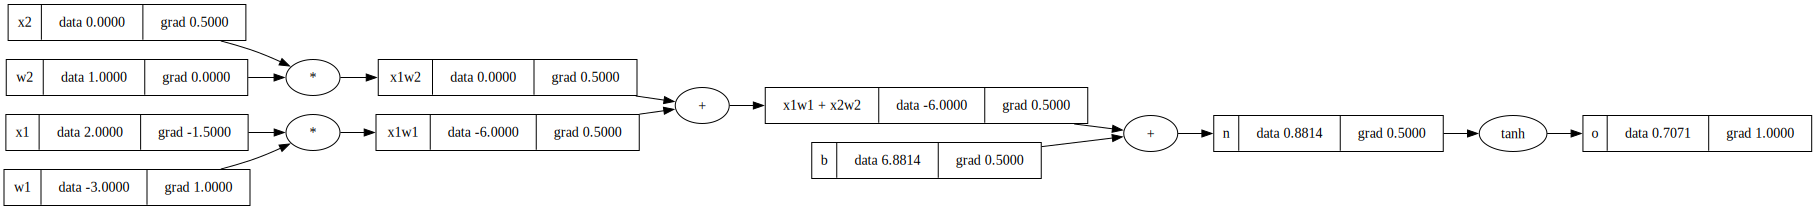

In [39]:
draw_dot(o)

### Automation for _backward()  
For that we will need topological sort. WHY?  
Because we can only implement backpropagation once the values of all the nodes have been calculated

In [40]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        # for non-leaf nodes
        for child in v._prev: # ._prev takes the pointer to the previous nodes. 
            build_topo(child)
        # for the leaf nodes 
        topo.append(v)
build_topo(o) # the traversal starts from `o`
topo # the order is from the leaf nodes to the child node. But for backprop we need it to be in reversed, and i.e. what we will do

[Value(data=6.881373587019543),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

We can try out the automated ._backwards() method

In [41]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b') # this value is just for calculation convenience

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x1w2' 
x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label = 'x1w1 + x2w2'

n = x1w1_x2w2 + b; n.label = 'n'
# now n is the raw cell body without the activation function.
# the activation function on top of n, we would be using would be tanh()

# adding the output axon `o` on the cell body `n`
o = n.tanh(); o.label = 'o'

In [42]:
o.grad = 1.0

In [43]:
build_topo(o)

In [44]:
for node in reversed(topo):
    node._backward()

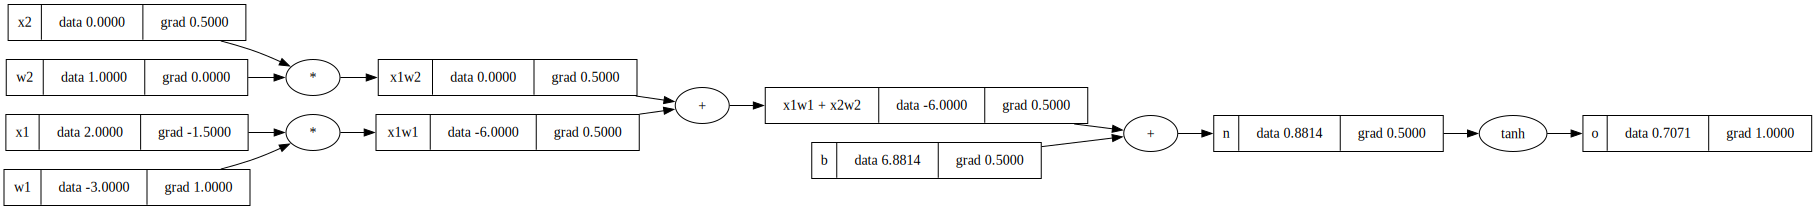

In [45]:
draw_dot(o)

Now merging everything into the `Value` class

In [46]:
class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        # _children is an empty tuple
        # _prev will be the empty set.
        self.grad = 0.0 # that means initially it has no effect
        self._backward = lambda: None
        self.data = data
        self._prev = set(_children) # designing it as a set; will have to see. might just be an efficiency thing. 
        # This will help in creating the linked-list
        self._op = _op # store which operation we did
        self.label = label # store the variable name. 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+') # this line is calling the __init__ itself

        def _backward():
            # taking reference from our manual backpropagation
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') # this line is calling the __init__ itself
        
        def _backward():
            # taking reference from our manual backpropagation
            self.grad = other.data * out.grad # taking reference from equ 1.
            other.grad = self.data * out.grad
            # But in real backprop, it will not just be other.data; it might be :-
            # (other1.data + other2.data + .....) * out.grad. 
            # This we will have to check. 
        out._backward = _backward
        
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1) # basically copying the formula of tanh mathematical expression
        out = Value(t, (self, ), 'tanh') # (self, ) means tuple of itself. 
        # WHY? because tanh() only requires one parameter. i.e. itself. 
        # whereas add() and mul() requires more than 1 parameter. 

        def _backward(): 
            self.grad = (1 - t**2) * out.grad 
            # or 
            # self.grad = (1 - out.value**2) * out.grad 
        out._backward = _backward

        return out

    # This will be called once 
    def backward(self):
        visited = set()
        topo = [] # topologically sorted list
        # related to automatic backpropagation, using topological sort
        def build_topo(node):
            if node not in visited:
                # first we have to add the node into the set 
                visited.add(node)
                # for non-leaf nodes, traverse their children first
                for child in node._prev:
                    build_topo(child)
                # for leaf nodes
                topo.append(node)
        # now call this sort from the last node, it will traverse the whole list using the ._prev variable.
        build_topo(self)

        # now for the calculation of backpropagation we have to traverse the list in a reversed way. 
        self.grad = 1.0 # value of gradient for the last node 
        for node in reversed(topo):
            node._backward()


In [47]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b') # this value is just for calculation convenience

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x1w2' 
x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label = 'x1w1 + x2w2'

n = x1w1_x2w2 + b; n.label = 'n'
# now n is the raw cell body without the activation function.
# the activation function on top of n, we would be using would be tanh()

# adding the output axon `o` on the cell body `n`
o = n.tanh(); o.label = 'o'

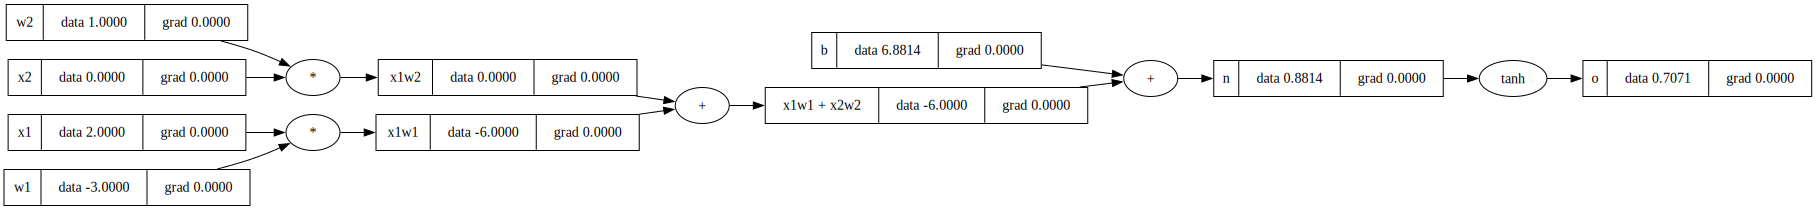

In [48]:
draw_dot(o)

In [49]:
o.backward()

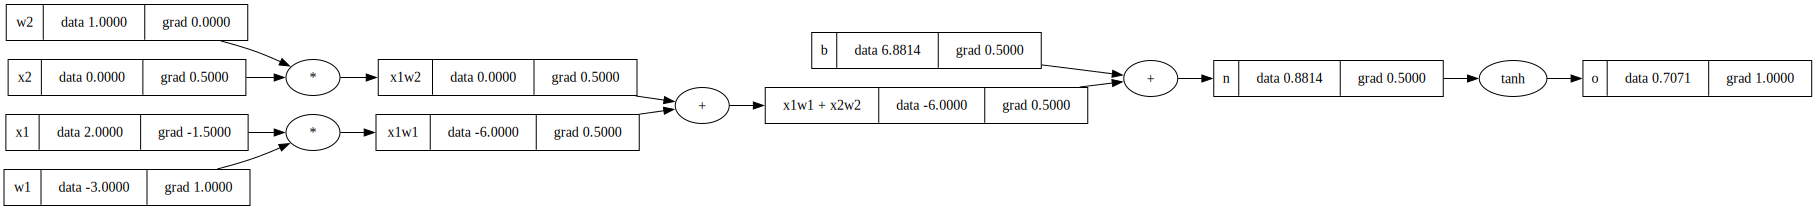

In [50]:
draw_dot(o)

This is the backpropagation for 1 neuron

### Exploring the bugs in this version of the backpropagation  
This is the multivariate case of the `chain rule` of derivatives

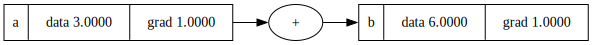

In [51]:
a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

Now here the `a.grad` or $\frac{db}{da}$ is not correct  
$$
\frac{db}{da} = \frac{d(a + a)}{da} \\
\frac{db}{da} = \frac{da}{da} + \frac{da}{da} \\
\boxed{\frac{db}{da} = 2}
$$

But in our case `b.backward()` is `1.0`. Which is wrong.  
The same problem will arise if we use the `multiplication` or any other `math` operator. 
REASON:  
The way we framed the `._backward()`, is that if we if a variable is used multiple times, then its `.grad` is getting overwritten.  
Taking another example with other `math` operations will make it more clear

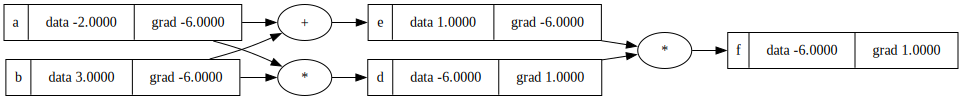

In [52]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a * b; d.label='d'
e = a + b; e.label='e'
f = d * e; f.label='f'

f.backward()

draw_dot(f)

SOLUTION: The gradient accumulates.  
That means for each variable we will have to add their gradient contribution by a `math` operation by a particular child `node`.  
EXAMPLE: In the above case, `a.grad` should have the gradient contributions from `e` and `d`.  
Now we will modify the `Value` class.

In [53]:
class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        # _children is an empty tuple
        # _prev will be the empty set.
        self.grad = 0.0 # that means initially it has no effect
        self._backward = lambda: None
        self.data = data
        self._prev = set(_children) # designing it as a set; will have to see. might just be an efficiency thing. 
        # This will help in creating the linked-list
        self._op = _op # store which operation we did
        self.label = label # store the variable name. 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+') # this line is calling the __init__ itself

        def _backward():
            # taking reference from our manual backpropagation
            self.grad += 1.0 * out.grad # modified the contribution, to avoid over-write
            other.grad += 1.0 * out.grad # modified the contribution, to avoid over-write
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') # this line is calling the __init__ itself
        
        def _backward():
            # taking reference from our manual backpropagation
            self.grad += other.data * out.grad # modified the contribution, to avoid over-write
            other.grad += self.data * out.grad # modified the contribution, to avoid over-write
            # But in real backprop, it will not just be other.data; it might be :-
            # (other1.data + other2.data + .....) * out.grad. 
            # This we will have to check. 
        out._backward = _backward
        
        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1) # basically copying the formula of tanh mathematical expression
        out = Value(t, (self, ), 'tanh') # (self, ) means tuple of itself. 
        # WHY? because tanh() only requires one parameter. i.e. itself. 
        # whereas add() and mul() requires more than 1 parameter. 

        def _backward(): 
            self.grad += (1 - t**2) * out.grad # modified the contribution, to avoid over-write
            # or 
            # self.grad = (1 - out.value**2) * out.grad 
        out._backward = _backward

        return out

    # This will be called once 
    def backward(self):
        visited = set()
        topo = [] # topologically sorted list
        # related to automatic backpropagation, using topological sort
        def build_topo(node):
            if node not in visited:
                # first we have to add the node into the set 
                visited.add(node)
                # for non-leaf nodes, traverse their children first
                for child in node._prev:
                    build_topo(child)
                # for leaf nodes
                topo.append(node)
        # now call this sort from the last node, it will traverse the whole list using the ._prev variable.
        build_topo(self)

        # now for the calculation of backpropagation we have to traverse the list in a reversed way. 
        self.grad = 1.0 # value of gradient for the last node 
        for node in reversed(topo):
            node._backward()


Now lets check the same equations

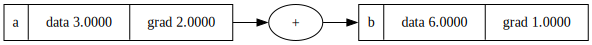

In [54]:
a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

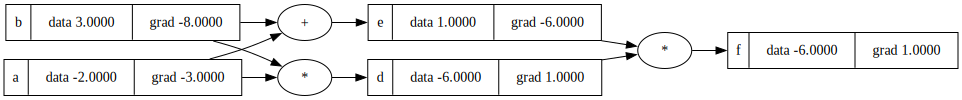

In [55]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a * b; d.label='d'
e = a + b; e.label='e'
f = d * e; f.label='f'

f.backward()

draw_dot(f)

## Handling `edge` case in the `Value` class  
Adding all the most common `math` operators in the `Value` class  
$\therefore$ we would be adding the following functions:  
- $e$ : exponent  
- $-$ : substract  
- $/$ : division  

Also other modifications we are adding to the codebase:  
```python
a = Value(2.0)
2 * a # this will not work
a * 2 # this will work  
```
because ``` 2 * a ``` actually calls ```2.__mul(a)```. so we have to reverse it.  

SOLUTION:
`__rmul__` is only for multiplication.

It is the ```right-side multiplication``` hook, used when Python sees something like:

```python
2 * value
```

If that doesn't work, then Python will look it the other variant works, and if yes then it will try: 

```python
value.__rmul__(2)
```











For ```addition```, the equivalent is:

- `__radd__`

Example:
```python
2 + value
```

may call:
```python
value.__radd__(2)
```



In [ ]:
import math 

class Value:
    
    def __init__(self, data, _children=(), _op='', label=''):
        # _children is an empty tuple
        # _prev will be the empty set.
        self.grad = 0.0 # that means initially it has no effect
        self._backward = lambda: None
        self.data = data
        self._prev = set(_children) # designing it as a set; will have to see. might just be an efficiency thing. 
        # This will help in creating the linked-list
        self._op = _op # store which operation we did
        self.label = label # store the variable name. 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # this is for doing something like a + 1
        # basically converts anything which is not of type `Value` to `Value`
        out = Value(self.data + other.data, (self, other), '+') 
 
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad 
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*') 
        
        def _backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad 
        out._backward = _backward
        
        return out
        
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float for now"
        out = Value(self.data**other, (self,), f'**{other}') # self.data^(other)

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad # d(x^n)/dx = n.x^(n-1)
        out._backward = _backward

        return out
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1) # basically copying the formula of tanh mathematical expression
        out = Value(t, (self, ), 'tanh') # (self, ) means tuple of itself. 
        # WHY? because tanh() only requires one parameter. i.e. itself. 
        # whereas add() and mul() requires more than 1 parameter. 

        def _backward(): 
            self.grad += (1 - t**2) * out.grad # modified the contribution, to avoid over-write
            # or 
            # self.grad = (1 - out.value**2) * out.grad 
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad # out.data as d(e^x)/dx = e^x
        out._backward = _backward

        return out

    ## For the following methods, before backward, we haven't called backward() or calculated the .grad()
    # REASON: these methods will be calling the other methods like __add__() and __muk__() while returning
    def __rmul__(self, other): # other * self 
        return self * other 
    
    def __radd__(self, other): # other + self
        return self + other
    
    def __truediv__(self, other): # self / other
        # a / b = a * b^(-1)
        # this is more generic and will be helpful later.
        return self * other**-1
    
    def __neg__(self): # self
        return self * - 1
    
    def __sub__(self, other): # self - other
        return self + (-other)


    # This will be called once 
    def backward(self):
        visited = set()
        topo = [] # topologically sorted list
        # related to automatic backpropagation, using topological sort
        def build_topo(node):
            if node not in visited:
                # first we have to add the node into the set 
                visited.add(node)
                # for non-leaf nodes, traverse their children first
                for child in node._prev:
                    build_topo(child)
                # for leaf nodes
                topo.append(node)
        # now call this sort from the last node, it will traverse the whole list using the ._prev variable.
        build_topo(self)

        # now for the calculation of backpropagation we have to traverse the list in a reversed way. 
        self.grad = 1.0 # value of gradient for the last node 
        for node in reversed(topo):
            node._backward()


Breaking up the `tanh` method

In [57]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron
b = Value(6.8813735870195432, label = 'b') # this value is just for calculation convenience

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x1w2' 
x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label = 'x1w1 + x2w2'

n = x1w1_x2w2 + b; n.label = 'n'

# o = n.tanh(); o.label = 'o'
# Instead of this we would be breaking it down

$$
\tanh(n) = \frac{e^n - e^{-n}}{e^n + e^{-n}}
$$
or   
$$
\boxed{\tanh(n) = \frac{e^{2n} - 1}{e^{2n} + 1}}
$$


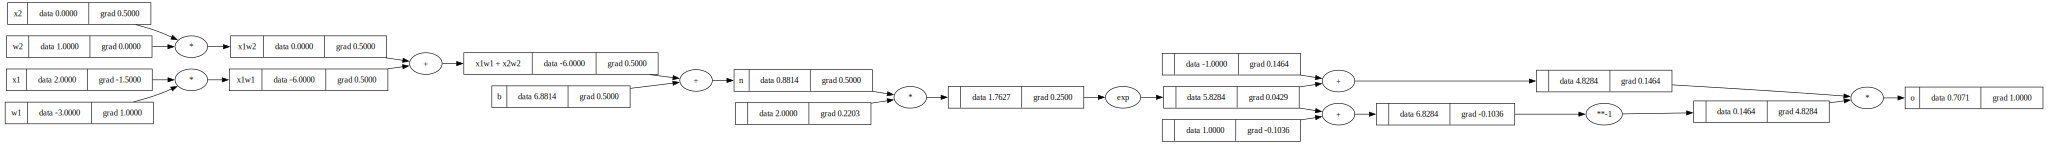

In [58]:
e = (2*n).exp()
o = (e - 1)/(e + 1) 
o.label = 'o'
o.backward()
draw_dot(o)

Explanation for the ```**-1``` in the computation node:  
It comes from your division rewrite.

You wrote:

```python
def __truediv__(self, other):  # self / other
    return self * other**-1
```

So when you do:

```python
o = (e - 1) / (e + 1)
```

Python interprets it as:

```python
o = (e - 1) * ((e + 1) ** -1)
```

That means the denominator is turned into a power node with exponent `-1`.

Why `**-1`?
- mathematically,
  \[
  \frac{a}{b} = a \cdot b^{-1}
  \]
- so instead of implementing division separately, you reuse:
  - multiplication
  - power

So the computation graph gets a node whose operation label is:

```python
'**-1'
```

because in `__pow__` you created it like:

```python
out = Value(self.data**other, (self,), f'**{other}')
```

and here `other = -1`.

Concrete flow:
1. `(e + 1)` creates a `Value`
2. `(e + 1) ** -1` creates a new `Value` with:
   - data = reciprocal
   - `_prev = {(e + 1)}`
   - `_op = '**-1'`
3. `(e - 1) * ((e + 1) ** -1)` creates the multiplication node

So `**-1` is the reciprocal node introduced by your `__truediv__` implementation.